# Retailrocket E-commerce Funnel Analysis
## Notebook 02 — Funnel Analysis

### Цель ноутбука
В этом ноутбуке:
- рассчитывается базовая пользовательская воронка
- строится строгая последовательная воронка
- анализируется время до конверсии
- сравнивается поведение покупателей и непокупателей

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
events = pd.read_csv('data/events_clean.csv')
events.head()

,Unnamed: 0,timestamp,visitorid,event,itemid,transactionid,event_time,event_date,event_week,event_month,event_hour,event_dayofweek
0,0,1433221332117,257597,view,355908,NaN,2015-06-02 05:02:12.117,2015-06-02,2015-06-01/2015-06-07,2015-06,5,Tuesday
1,1,1433224214164,992329,view,248676,NaN,2015-06-02 05:50:14.164,2015-06-02,2015-06-01/2015-06-07,2015-06,5,Tuesday
2,2,1433221999827,111016,view,318965,NaN,2015-06-02 05:13:19.827,2015-06-02,2015-06-01/2015-06-07,2015-06,5,Tuesday
3,3,1433221955914,483717,view,253185,NaN,2015-06-02 05:12:35.914,2015-06-02,2015-06-01/2015-06-07,2015-06,5,Tuesday
4,4,1433221337106,951259,view,367447,NaN,2015-06-02 05:02:17.106,2015-06-02,2015-06-01/2015-06-07,2015-06,5,Tuesday


## 2. Базовая пользовательская воронка

Сначала построим простую воронку по пользователям:
- пользователь видел хотя бы один товар
- пользователь хотя бы раз добавлял товар в корзину
- пользователь хотя бы раз совершал покупку

In [3]:
user_events = (
    events.assign(flag=1)
    .pivot_table(
        index="visitorid",
        columns="event",
        values="flag",
        aggfunc="max",
        fill_value=0
    )
    .reset_index()
)
user_events.head(15)

event,visitorid,addtocart,transaction,view
0,0,0,0,1
1,1,0,0,1
2,2,0,0,1
3,3,0,0,1
4,4,0,0,1
5,5,0,0,1
6,6,1,0,1
7,7,0,0,1
8,8,0,0,1
9,9,0,0,1


In [4]:
users_view = (user_events["view"] == 1).sum()
users_cart = (user_events["addtocart"] == 1).sum()
users_transaction = (user_events["transaction"] == 1).sum()
funnel_basic = pd.DataFrame({
    "stage": ["view", "addtocart", "transaction"],
    "users": [users_view, users_cart, users_transaction]
})
funnel_basic["conversion_from_previous"] = [
    1.0,
    users_cart / users_view if users_view else np.nan,
    users_transaction / users_cart if users_cart else np.nan
]
funnel_basic["conversion_from_view"] = [
    1.0,
    users_cart / users_view if users_view else np.nan,
    users_transaction / users_view if users_view else np.nan
]
funnel_basic["drop_from_previous"] = 1 - funnel_basic["conversion_from_previous"]
funnel_basic

,stage,users,conversion_from_previous,conversion_from_view,drop_from_previous
0,view,1404179,1.000000,1.000000,0.000000
1,addtocart,37722,0.026864,0.026864,0.973136
2,transaction,11719,0.310668,0.008346,0.689332


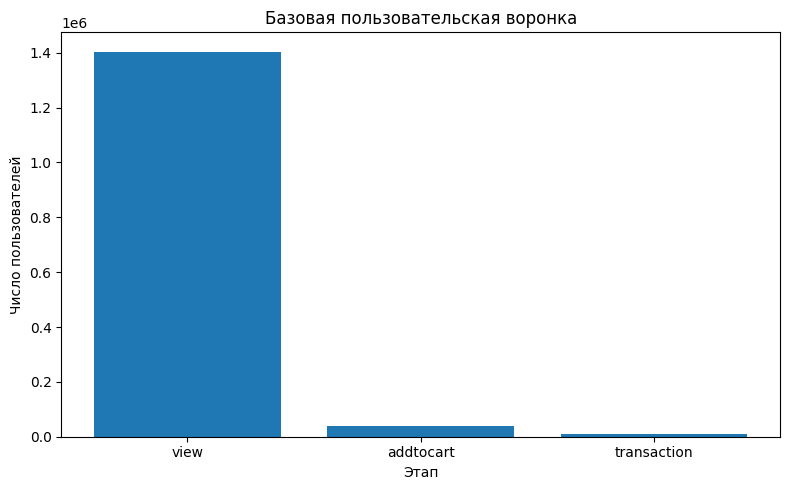

In [5]:
plt.figure(figsize=(8, 5))
plt.bar(funnel_basic["stage"], funnel_basic["users"])
plt.title("Базовая пользовательская воронка")
plt.xlabel("Этап")
plt.ylabel("Число пользователей")
plt.tight_layout()
plt.show()

## 3. Строгая последовательная воронка

Теперь построим более коректную воронку:
- для каждого пользователя найдем время первого `view`
- первого `addtocart`
- первого `transaction`
- и проверим, что порядок событий логически корректен:

`first_view <= first_addtocart <= first_transaction`

Это позволяет отделить простое наличие событий от реального пользовательского пути

In [6]:
first_events = (
    events.groupby(["visitorid", "event"])["event_time"]
    .min()
    .unstack()
    .reset_index()
)
for col in ["view", "addtocart", "transaction"]:
    if col not in first_events.columns:
        first_events[col] = pd.NaT
    first_events[col] = pd.to_datetime(first_events[col], errors="coerce")
first_events.head(7)

event,visitorid,addtocart,transaction,view
0,0,NaT,NaT,2015-09-11 20:49:49.439
1,1,NaT,NaT,2015-08-13 17:46:06.444
2,2,NaT,NaT,2015-08-07 17:51:44.567
3,3,NaT,NaT,2015-08-01 07:10:35.296
4,4,NaT,NaT,2015-09-15 21:24:27.167
5,5,NaT,NaT,2015-07-17 01:45:56.439
6,6,2015-08-30 06:03:48.202,NaT,2015-08-30 06:39:38.318


In [7]:
invalid_cart_before_view = (
    first_events["addtocart"].notna() &
    first_events["view"].notna() &
    (first_events["addtocart"] < first_events["view"])
).sum()
invalid_transaction_before_cart = (
    first_events["transaction"].notna() &
    first_events["addtocart"].notna() &
    (first_events["transaction"] < first_events["addtocart"])
).sum()
invalid_transaction_before_view = (
    first_events["transaction"].notna() &
    first_events["view"].notna() &
    (first_events["transaction"] < first_events["view"])
).sum()
n_users_first = len(first_events)
print("Число пользователей с addtocart < view:", round(invalid_cart_before_view / n_users_first, 4))
print("Число пользователей с transaction < addtocart:", round(invalid_transaction_before_cart / n_users_first, 4))
print("Число пользователей с transaction < view:", round(invalid_transaction_before_view / n_users_first, 4))
print("Пользователи с addtocart раньше чем first view :", invalid_cart_before_view)
print("Пользователи с transaction раньше чем first addtocart:", invalid_transaction_before_cart)
print("Пользователи с transaction раньше чем first view:", invalid_transaction_before_view)

Число пользователей с addtocart < view: 0.0015
Число пользователей с transaction < addtocart: 0.0001
Число пользователей с transaction < view: 0.0001
Пользователи с addtocart раньше чем first view : 2129
Пользователи с transaction раньше чем first addtocart: 129
Пользователи с transaction раньше чем first view: 181


In [8]:
first_events["has_view"] = first_events["view"].notna().astype(int)
first_events["has_cart_after_view"] = (
    first_events["addtocart"].notna() &
    first_events["view"].notna() &
    (first_events["addtocart"] >= first_events["view"])
).astype(int)
first_events["has_transaction_after_cart"] = (
    first_events["transaction"].notna() &
    first_events["addtocart"].notna() &
    first_events["view"].notna() &
    (first_events["addtocart"] >= first_events["view"]) &
    (first_events["transaction"] >= first_events["addtocart"])
).astype(int)
first_events.head(7)

event,visitorid,addtocart,transaction,view,has_view,has_cart_after_view,has_transaction_after_cart
0,0,NaT,NaT,2015-09-11 20:49:49.439,1,0,0
1,1,NaT,NaT,2015-08-13 17:46:06.444,1,0,0
2,2,NaT,NaT,2015-08-07 17:51:44.567,1,0,0
3,3,NaT,NaT,2015-08-01 07:10:35.296,1,0,0
4,4,NaT,NaT,2015-09-15 21:24:27.167,1,0,0
5,5,NaT,NaT,2015-07-17 01:45:56.439,1,0,0
6,6,2015-08-30 06:03:48.202,NaT,2015-08-30 06:39:38.318,1,0,0


In [9]:
strict_view = first_events["has_view"].sum()
strict_cart = first_events["has_cart_after_view"].sum()
strict_transaction = first_events["has_transaction_after_cart"].sum()
funnel_strict = pd.DataFrame({
    "stage": ["view", "addtocart_after_view", "transaction_after_cart"],
    "users": [strict_view, strict_cart, strict_transaction]
})
funnel_strict["conversion_from_previous"] = [
    1.0,
    strict_cart / strict_view if strict_view else np.nan,
    strict_transaction / strict_cart if strict_cart else np.nan
]
funnel_strict["conversion_from_view"] = [
    1.0,
    strict_cart / strict_view if strict_view else np.nan,
    strict_transaction / strict_view if strict_view else np.nan
]
funnel_strict["drop_from_previous"] = 1 - funnel_strict["conversion_from_previous"]
funnel_strict

,stage,users,conversion_from_previous,conversion_from_view,drop_from_previous
0,view,1404179,1.000000,1.000000,0.000000
1,addtocart_after_view,32272,0.022983,0.022983,0.977017
2,transaction_after_cart,9682,0.300012,0.006895,0.699988


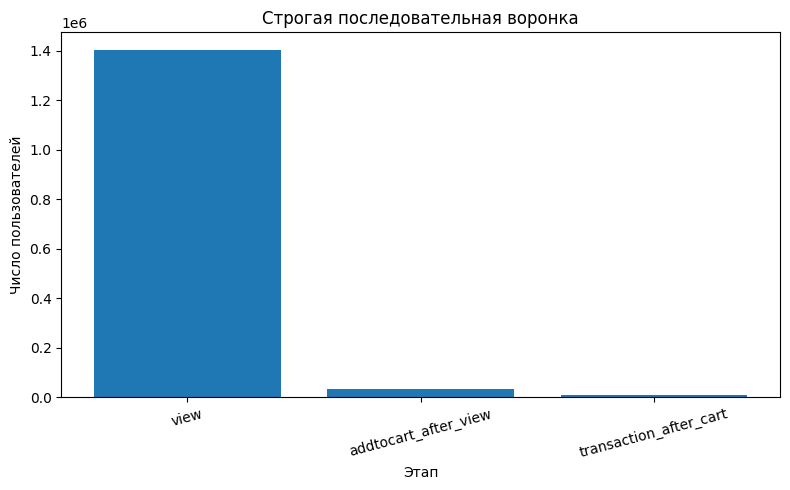

In [10]:
plt.figure(figsize=(8, 5))
plt.bar(funnel_strict["stage"], funnel_strict["users"])
plt.title("Строгая последовательная воронка")
plt.xlabel("Этап")
plt.ylabel("Число пользователей")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [11]:
funnel_compare = pd.DataFrame({
    "stage": ["view", "addtocart", "transaction"],
    "basic_users": [users_view, users_cart, users_transaction],
    "strict_users": [strict_view, strict_cart, strict_transaction]
})
funnel_compare["difference"] = funnel_compare["basic_users"] - funnel_compare["strict_users"]
funnel_compare

,stage,basic_users,strict_users,difference
0,view,1404179,1404179,0
1,addtocart,37722,32272,5450
2,transaction,11719,9682,2037


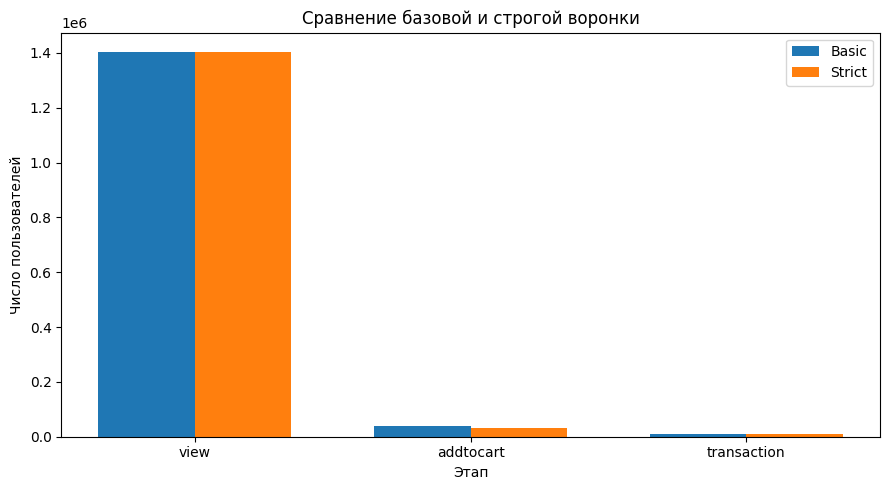

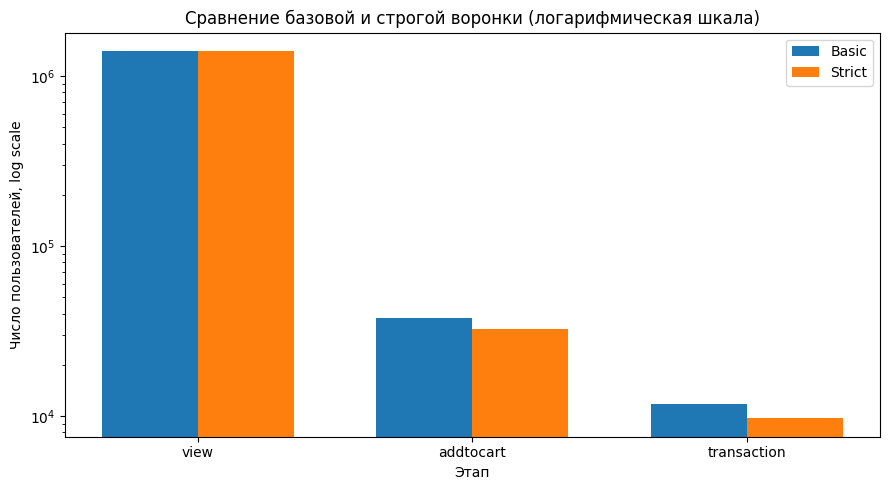

In [12]:
x = np.arange(len(funnel_compare))
width = 0.35
plt.figure(figsize=(9, 5))
plt.bar(x - width/2, funnel_compare["basic_users"], width, label="Basic")
plt.bar(x + width/2, funnel_compare["strict_users"], width, label="Strict")
plt.xticks(x, funnel_compare["stage"])
plt.title("Сравнение базовой и строгой воронки")
plt.xlabel("Этап")
plt.ylabel("Число пользователей")
plt.legend()
plt.tight_layout()
plt.show()
plt.figure(figsize=(9, 5))
plt.bar(x - width/2, funnel_compare["basic_users"], width, label="Basic")
plt.bar(x + width/2, funnel_compare["strict_users"], width, label="Strict")
plt.xticks(x, funnel_compare["stage"])
plt.title("Сравнение базовой и строгой воронки (логарифмическая шкала)")
plt.xlabel("Этап")
plt.ylabel("Число пользователей, log scale")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Время до конверсии

Теперь оценим, сколько времени проходит:
- от первого просмотра до первого добавления в корзину
- от первого добавления в корзину до первой покупки
- от первого просмотра до первой покупки
  
Это помогает понять, как быстро пользователи принимают решение

In [13]:
conversion_time = first_events.copy()
conversion_time["view_to_cart_hours"] = (
    (conversion_time["addtocart"] - conversion_time["view"]).dt.total_seconds() / 3600
)
conversion_time["cart_to_transaction_hours"] = (
    (conversion_time["transaction"] - conversion_time["addtocart"]).dt.total_seconds() / 3600
)
conversion_time["view_to_transaction_hours"] = (
    (conversion_time["transaction"] - conversion_time["view"]).dt.total_seconds() / 3600
)
conversion_time.head(7)

event,visitorid,addtocart,transaction,view,has_view,has_cart_after_view,has_transaction_after_cart,view_to_cart_hours,cart_to_transaction_hours,view_to_transaction_hours
0,0,NaT,NaT,2015-09-11 20:49:49.439,1,0,0,NaN,NaN,NaN
1,1,NaT,NaT,2015-08-13 17:46:06.444,1,0,0,NaN,NaN,NaN
2,2,NaT,NaT,2015-08-07 17:51:44.567,1,0,0,NaN,NaN,NaN
3,3,NaT,NaT,2015-08-01 07:10:35.296,1,0,0,NaN,NaN,NaN
4,4,NaT,NaT,2015-09-15 21:24:27.167,1,0,0,NaN,NaN,NaN
5,5,NaT,NaT,2015-07-17 01:45:56.439,1,0,0,NaN,NaN,NaN
6,6,2015-08-30 06:03:48.202,NaT,2015-08-30 06:39:38.318,1,0,0,-0.597254,NaN,NaN


In [14]:
conversion_time.loc[conversion_time["view_to_cart_hours"] < 0, "view_to_cart_hours"] = np.nan
conversion_time.loc[conversion_time["cart_to_transaction_hours"] < 0, "cart_to_transaction_hours"] = np.nan
conversion_time.loc[conversion_time["view_to_transaction_hours"] < 0, "view_to_transaction_hours"] = np.nan

In [15]:
time_summary = pd.DataFrame({
    "metric": [
        "view_to_cart_hours",
        "cart_to_transaction_hours",
        "view_to_transaction_hours"
    ],
    "mean_hours": [
        conversion_time["view_to_cart_hours"].mean(),
        conversion_time["cart_to_transaction_hours"].mean(),
        conversion_time["view_to_transaction_hours"].mean()
    ],
    "median_hours": [
        conversion_time["view_to_cart_hours"].median(),
        conversion_time["cart_to_transaction_hours"].median(),
        conversion_time["view_to_transaction_hours"].median()
    ],
    "p75_hours": [
        conversion_time["view_to_cart_hours"].quantile(0.75),
        conversion_time["cart_to_transaction_hours"].quantile(0.75),
        conversion_time["view_to_transaction_hours"].quantile(0.75)
    ]
})
time_summary

,metric,mean_hours,median_hours,p75_hours
0,view_to_cart_hours,76.129904,0.061753,0.608179
1,cart_to_transaction_hours,13.878468,0.097426,0.267390
2,view_to_transaction_hours,95.533242,0.351690,6.362595


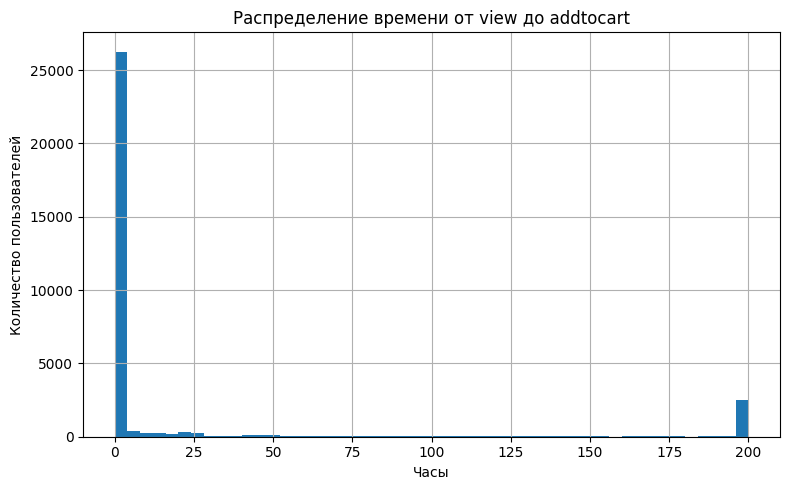

In [16]:
plt.figure(figsize=(8, 5))
conversion_time["view_to_cart_hours"].dropna().clip(upper=200).hist(bins=50)
plt.title("Распределение времени от view до addtocart")
plt.xlabel("Часы")
plt.ylabel("Количество пользователей")
plt.tight_layout()
plt.show()

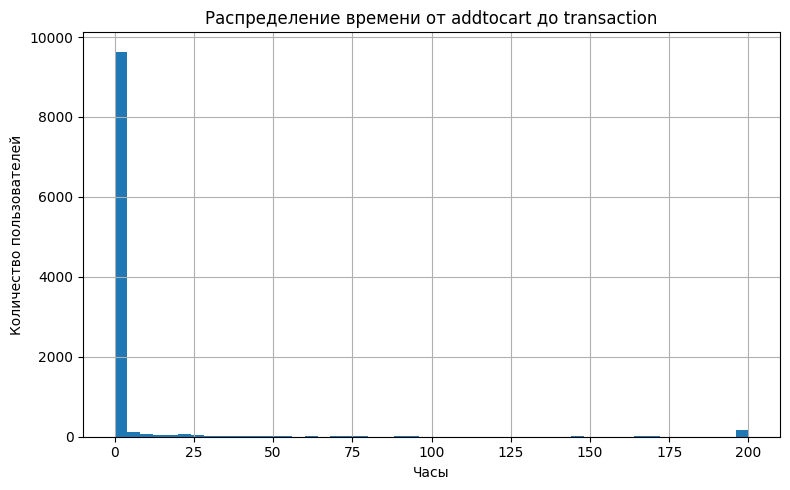

In [17]:
plt.figure(figsize=(8, 5))
conversion_time["cart_to_transaction_hours"].dropna().clip(upper=200).hist(bins=50)
plt.title("Распределение времени от addtocart до transaction")
plt.xlabel("Часы")
plt.ylabel("Количество пользователей")
plt.tight_layout()
plt.show()

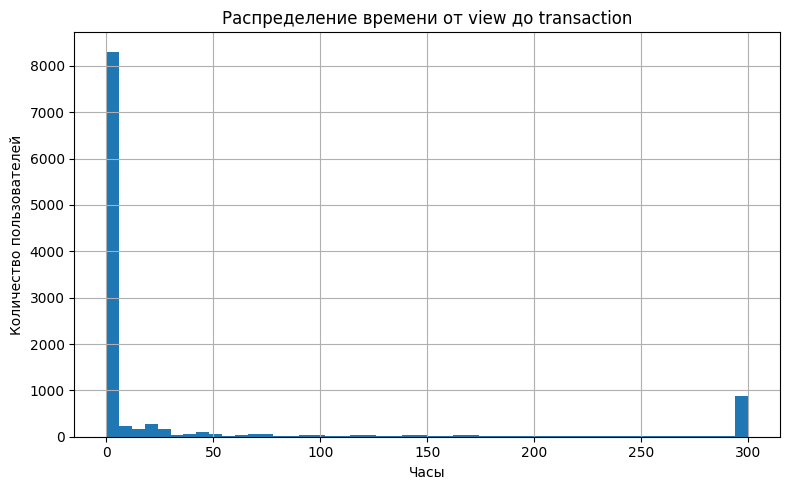

In [18]:
plt.figure(figsize=(8, 5))
conversion_time["view_to_transaction_hours"].dropna().clip(upper=300).hist(bins=50)
plt.title("Распределение времени от view до transaction")
plt.xlabel("Часы")
plt.ylabel("Количество пользователей")
plt.tight_layout()
plt.show()

## 5. Сравнение покупателей и непокупателей

Теперь сравним поведение пользователей:
- покупатели — пользователи, у которых был `transaction`
- непокупатели — пользователи без покупки

Сравним их по числу событий, просмотров, корзин и уникальных товаров

In [19]:
event_counts_by_user = (
    pd.crosstab(events["visitorid"], events["event"])
    .reset_index()
)
for col in ["view", "addtocart", "transaction"]:
    if col not in event_counts_by_user.columns:
        event_counts_by_user[col] = 0
event_counts_by_user = event_counts_by_user.rename(columns={
    "view": "total_views",
    "addtocart": "total_addtocart",
    "transaction": "total_transactions"
})
event_counts_by_user["total_events"] = (
    event_counts_by_user["total_views"] +
    event_counts_by_user["total_addtocart"] +
    event_counts_by_user["total_transactions"]
)
event_counts_by_user.head(10)

event,visitorid,total_addtocart,total_transactions,total_views,total_events
0,0,0,0,3,3
1,1,0,0,1,1
2,2,0,0,8,8
3,3,0,0,1,1
4,4,0,0,1,1
5,5,0,0,1,1
6,6,1,0,5,6
7,7,0,0,3,3
8,8,0,0,1,1
9,9,0,0,1,1


In [20]:
unique_items_by_user = (
    events.groupby("visitorid")["itemid"]
    .nunique()
    .reset_index(name="unique_items")
)
unique_items_by_user.head(10)

,visitorid,unique_items
0,0,3
1,1,1
2,2,4
3,3,1
4,4,1
5,5,1
6,6,3
7,7,3
8,8,1
9,9,1


In [21]:
time_bounds_by_user = (
    events.groupby("visitorid")["event_time"]
    .agg(first_event_time="min", last_event_time="max")
    .reset_index()
)
time_bounds_by_user.head()

,visitorid,first_event_time,last_event_time
0,0,2015-09-11 20:49:49.439,2015-09-11 20:55:17.175
1,1,2015-08-13 17:46:06.444,2015-08-13 17:46:06.444
2,2,2015-08-07 17:51:44.567,2015-08-07 18:20:57.845
3,3,2015-08-01 07:10:35.296,2015-08-01 07:10:35.296
4,4,2015-09-15 21:24:27.167,2015-09-15 21:24:27.167


In [23]:
user_metrics = (
    event_counts_by_user
    .merge(unique_items_by_user, on="visitorid", how="left")
    .merge(time_bounds_by_user, on="visitorid", how="left")
)
print(user_metrics[["first_event_time", "last_event_time"]].dtypes)
user_metrics["first_event_time"] = pd.to_datetime(user_metrics["first_event_time"], errors="coerce")
user_metrics["last_event_time"] = pd.to_datetime(user_metrics["last_event_time"], errors="coerce")
user_metrics["is_buyer"] = (user_metrics["total_transactions"] > 0).astype(int)
user_metrics["lifetime_hours"] = (
    (user_metrics["last_event_time"] - user_metrics["first_event_time"]).dt.total_seconds() / 3600
)
user_metrics.head()

first_event_time    str
last_event_time     str
dtype: object


,visitorid,total_addtocart,total_transactions,total_views,total_events,unique_items,first_event_time,last_event_time,is_buyer,lifetime_hours
0,0,0,0,3,3,3,2015-09-11 20:49:49.439,2015-09-11 20:55:17.175,0,0.091038
1,1,0,0,1,1,1,2015-08-13 17:46:06.444,2015-08-13 17:46:06.444,0,0.000000
2,2,0,0,8,8,4,2015-08-07 17:51:44.567,2015-08-07 18:20:57.845,0,0.487022
3,3,0,0,1,1,1,2015-08-01 07:10:35.296,2015-08-01 07:10:35.296,0,0.000000
4,4,0,0,1,1,1,2015-09-15 21:24:27.167,2015-09-15 21:24:27.167,0,0.000000


In [24]:
buyer_vs_nonbuyer = (
    user_metrics.groupby("is_buyer")
    .agg(
        users=("visitorid", "count"),
        avg_total_events=("total_events", "mean"),
        median_total_events=("total_events", "median"),
        avg_views=("total_views", "mean"),
        avg_addtocart=("total_addtocart", "mean"),
        avg_unique_items=("unique_items", "mean"),
        avg_lifetime_hours=("lifetime_hours", "mean"),
        median_lifetime_hours=("lifetime_hours", "median")
    )
    .reset_index()
)
buyer_vs_nonbuyer["segment"] = buyer_vs_nonbuyer["is_buyer"].map({0: "non-buyer", 1: "buyer"})
buyer_vs_nonbuyer

,is_buyer,users,avg_total_events,median_total_events,avg_views,avg_addtocart,avg_unique_items,avg_lifetime_hours,median_lifetime_hours,segment
0,0,1395861,1.808944,1.0,1.779171,0.029774,1.456735,55.401648,0.000000,non-buyer
1,1,11719,19.677959,6.0,15.423074,2.338595,9.538271,248.793992,1.673488,buyer


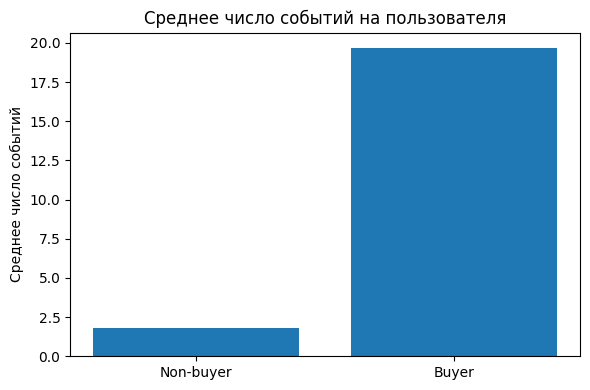

In [25]:
segment_stats = user_metrics.groupby("is_buyer")["total_events"].mean()
plt.figure(figsize=(6, 4))
plt.bar(["Non-buyer", "Buyer"], segment_stats.values)
plt.title("Среднее число событий на пользователя")
plt.ylabel("Среднее число событий")
plt.tight_layout()
plt.show()

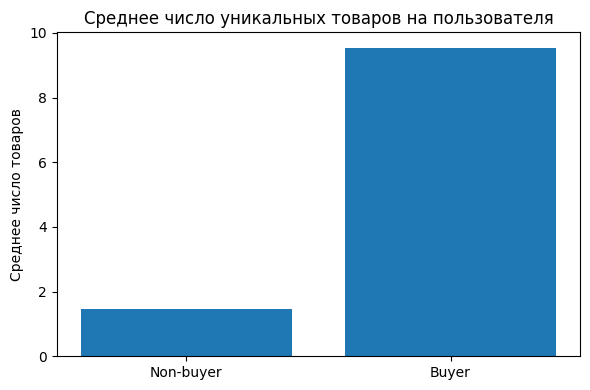

In [26]:
segment_items = user_metrics.groupby("is_buyer")["unique_items"].mean()
plt.figure(figsize=(6, 4))
plt.bar(["Non-buyer", "Buyer"], segment_items.values)
plt.title("Среднее число уникальных товаров на пользователя")
plt.ylabel("Среднее число товаров")
plt.tight_layout()
plt.show()

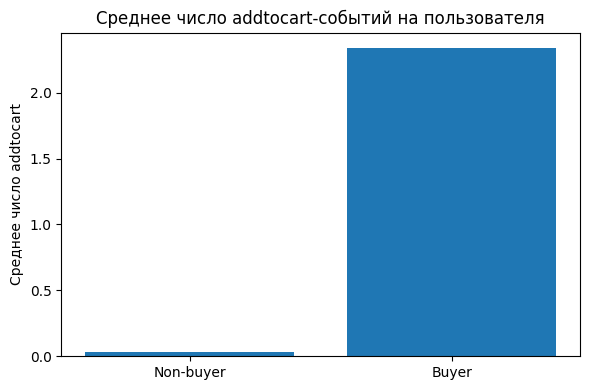

In [27]:
segment_cart = user_metrics.groupby("is_buyer")["total_addtocart"].mean()
plt.figure(figsize=(6, 4))
plt.bar(["Non-buyer", "Buyer"], segment_cart.values)
plt.title("Среднее число addtocart-событий на пользователя")
plt.ylabel("Среднее число addtocart")
plt.tight_layout()
plt.show()

## 6. Подготовка user-level таблицы для следующих этапов

Соберем итоговую пользовательскую таблицу, которая пригодится для последующих ноутбуков.

In [28]:
user_funnel = user_metrics.merge(
    first_events[[
        "visitorid", "view", "addtocart", "transaction",
        "has_view", "has_cart_after_view", "has_transaction_after_cart"
    ]],
    on="visitorid",
    how="left"
)
user_funnel = user_funnel.merge(
    conversion_time[[
        "visitorid",
        "view_to_cart_hours",
        "cart_to_transaction_hours",
        "view_to_transaction_hours"
    ]],
    on="visitorid",
    how="left"
)
user_funnel.head(10)

,visitorid,total_addtocart,total_transactions,total_views,total_events,unique_items,first_event_time,last_event_time,is_buyer,lifetime_hours,view,addtocart,transaction,has_view,has_cart_after_view,has_transaction_after_cart,view_to_cart_hours,cart_to_transaction_hours,view_to_transaction_hours
0,0,0,0,3,3,3,2015-09-11 20:49:49.439,2015-09-11 20:55:17.175,0,0.091038,2015-09-11 20:49:49.439,NaT,NaT,1,0,0,NaN,NaN,NaN
1,1,0,0,1,1,1,2015-08-13 17:46:06.444,2015-08-13 17:46:06.444,0,0.000000,2015-08-13 17:46:06.444,NaT,NaT,1,0,0,NaN,NaN,NaN
2,2,0,0,8,8,4,2015-08-07 17:51:44.567,2015-08-07 18:20:57.845,0,0.487022,2015-08-07 17:51:44.567,NaT,NaT,1,0,0,NaN,NaN,NaN
3,3,0,0,1,1,1,2015-08-01 07:10:35.296,2015-08-01 07:10:35.296,0,0.000000,2015-08-01 07:10:35.296,NaT,NaT,1,0,0,NaN,NaN,NaN
4,4,0,0,1,1,1,2015-09-15 21:24:27.167,2015-09-15 21:24:27.167,0,0.000000,2015-09-15 21:24:27.167,NaT,NaT,1,0,0,NaN,NaN,NaN
5,5,0,0,1,1,1,2015-07-17 01:45:56.439,2015-07-17 01:45:56.439,0,0.000000,2015-07-17 01:45:56.439,NaT,NaT,1,0,0,NaN,NaN,NaN
6,6,1,0,5,6,3,2015-08-30 06:03:48.202,2015-08-31 03:21:25.697,0,21.293749,2015-08-30 06:39:38.318,2015-08-30 06:03:48.202,NaT,1,0,0,NaN,NaN,NaN
7,7,0,0,3,3,3,2015-05-14 05:39:36.753,2015-05-16 04:20:39.214,0,46.684017,2015-05-14 05:39:36.753,NaT,NaT,1,0,0,NaN,NaN,NaN
8,8,0,0,1,1,1,2015-05-31 00:01:53.812,2015-05-31 00:01:53.812,0,0.000000,2015-05-31 00:01:53.812,NaT,NaT,1,0,0,NaN,NaN,NaN
9,9,0,0,1,1,1,2015-07-08 17:36:47.285,2015-07-08 17:36:47.285,0,0.000000,2015-07-08 17:36:47.285,NaT,NaT,1,0,0,NaN,NaN,NaN


In [29]:
funnel_basic.to_csv("data/funnel_basic.csv", index=False)
funnel_strict.to_csv("data/funnel_strict.csv", index=False)
user_funnel.to_csv("data/user_funnel.csv", index=False)
buyer_vs_nonbuyer.to_csv("data/buyer_vs_nonbuyer.csv", index=False)
time_summary.to_csv("data/time_summary.csv", index=False)

## 7. Выводы

По итогам анализа воронки можно сделать следующие наблюдения:

1. Базовая воронка показывает общую долю пользователей, дошедших до этапов `addtocart` и `transaction`
2. Строгая последовательная воронка позволяет точнее оценить реальный путь пользователя с учетом порядка событий
3. Сравнение базовой и строгой воронки показывает, насколько сильно итог зависит от методологии расчета
4. Анализ времени до конверсии помогает понять, быстро ли пользователи принимают решение о покупке
5. Сравнение покупателей и непокупателей позволяет выявить различия в интенсивности поведения и глубине взаимодействия с товарами